In [17]:
%pip cache purge
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
%pip install pandas
%pip install timm
%pip install scikit-learn

Files removed: 2 (38 kB)
Directories removed: 0
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [18]:
import os
import shutil
from pathlib import Path
import pandas as pd
import shutil
import random

import sys
from PIL import Image
import torch
import torchvision
import timm
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from collections import Counter


import torch.nn as nn


print("Using Python:", sys.executable)

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn tqdm timm

Using Python: /user/HS402/sm04533/Downloads/AMLv2/myenv/bin/python


In [19]:
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
Device count: 1
GPU: NVIDIA RTX A4000


In [20]:
# # Create main folder
# project_path = Path("./SplitDATA")
# project_path.mkdir(exist_ok=True)

# # Creating subfolders
# folders = [
#     "data/train/0", "data/train/1", "data/train/2", "data/train/3", "data/train/4",
#     "data/val/0", "data/val/1", "data/val/2", "data/val/3", "data/val/4",
#     "data/test/0", "data/test/1", "data/test/2", "data/test/3", "data/test/4",
#     "checkpoints",
#     "logs"
# ]

# for folder in folders:
#     (project_path / folder).mkdir(parents=True, exist_ok=True)
#     print(f"✓ Created: {folder}")

In [21]:


# # Read the labels CSV: image_name, DR_level (0, 1, 2, 3, or 4)
# try:
# 	labels_df = pd.read_csv("trainLabels.csv/trainLabels.csv")
# except PermissionError as e:
# 	print(f"PermissionError: {e}. Error file 'trainLabels.csv!! ")
# 	labels_df = pd.DataFrame()
# print("First 10 rows:")
# print(labels_df.head(10))

# print(f"\nTotal images: {len(labels_df)}")

# # Count how many of each class
# print("\nClass distribution:")
# print(labels_df['level'].value_counts().sort_index())

In [22]:
# #arranging the data into train, val and test sets

# # forLoad labels
# labels_df = pd.read_csv("trainLabels.csv/trainLabels.csv")

# # for Base paths
# images_raw_path = Path("train_images_compressed")
# data_path = Path("SplitDATA/data")

# # random seed for reproducibility
# random.seed(42)

# # Group images by class
# for class_level in range(5):  
#     ### 0, 1, 2, 3, 4
#     class_images = labels_df[labels_df['level'] == class_level]['image'].values
#     class_images = list(class_images)
    
#     random.shuffle(class_images)
    
#     # Calculate split
#     total = len(class_images)
#     train_size = int(total * 0.6)  # 60%
#     val_size = int(total * 0.2)    # 20%
    
#     train_imgs = class_images[:train_size]
#     val_imgs = class_images[train_size:train_size + val_size]
#     test_imgs = class_images[train_size + val_size:]
    
#     print(f"\nClass {class_level}:")
#     print(f"  Total: {total}")
#     print(f"  Train: {len(train_imgs)} (60%)")
#     print(f"  Val:   {len(val_imgs)} (20%)")
#     print(f"  Test:  {len(test_imgs)} (20%)")
    
#     # Copying train images
#     for img_name in train_imgs:
#         src = images_raw_path / f"{img_name}.jpg"
#         dst = data_path / "train" / str(class_level) / f"{img_name}.jpg"
        
#         if src.exists():
#             shutil.copy2(src, dst)
    
#     # Copying val images
#     for img_name in val_imgs:
#         src = images_raw_path / f"{img_name}.jpg"
#         dst = data_path / "val" / str(class_level) / f"{img_name}.jpg"
        
#         if src.exists():
#             shutil.copy2(src, dst)
    
#     # Copying test images
#     for img_name in test_imgs:
#         src = images_raw_path / f"{img_name}.jpg"
#         dst = data_path / "test" / str(class_level) / f"{img_name}.jpg"
        
#         if src.exists():
#             shutil.copy2(src, dst)

# print("\nImages organized!")

In [23]:
# # to verify Data Organization
# from pathlib import Path
# data_path = Path("SplitDATA/data")
# class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

# print("Base path exists:", data_path.exists())
# print("Base path:", data_path)

# for split in ["train", "val", "test"]:
#     print(f"\n{split.upper()} Set:")
#     total_split = 0

#     split_path = data_path / split
#     print(f"  Split path exists: {split_path.exists()} -> {split_path}")

#     for class_level in range(5):
#         class_dir = split_path / str(class_level)

#         if not class_dir.exists():
#             num_images = 0
#         else:
#             num_images = len(list(class_dir.glob("*.jpg"))) + len(list(class_dir.glob("*.jpeg"))) + len(list(class_dir.glob("*.png")))

#         total_split += num_images
#         print(f"  Class {class_level} ({class_names[class_level]:17s}): {num_images:5d} images")

#     print(f"  {'-' * 40}")
#     print(f"  Total {split}: {total_split} images")

# ##print("\nOverall verification complete!")

In [24]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = Path("SplitDATA") / "data"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

MODEL_NAME = "deit_small_distilled_patch16_224"
TEACHER_NAME = "regnety_160"

NUM_EPOCHS = 12
TEACHER_EPOCHS = 12
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.05
ALPHA = 0.5
TAU = 1.0
PATIENCE = 5


In [25]:
class DRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.images = []
        self.labels = []

        for label in range(NUM_CLASSES):
            class_dir = self.root_dir / str(label)
            if class_dir.exists():
                for ext in ["*.jpg", "*.jpeg", "*.png"]:
                    for img_path in class_dir.glob(ext):
                        self.images.append(str(img_path))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label


train_transform = transforms.Compose([
    #transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    #transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


train_dataset = DRDataset(TRAIN_DIR, transform=train_transform)
val_dataset = DRDataset(VAL_DIR, transform=val_test_transform)
test_dataset = DRDataset(TEST_DIR, transform=val_test_transform)

print(f"Train dataset: {len(train_dataset)} images")
print(f"Val dataset:   {len(val_dataset)} images")
print(f"Test dataset:  {len(test_dataset)} images")

#imbalance cls
class_counts = Counter(train_dataset.labels)
print("Class counts:", class_counts)

class_weights = torch.tensor(
    [1.0 / class_counts[i] for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(DEVICE)

print("Class weights:", class_weights)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("\nData loaders ready!")

Train dataset: 21073 images
Val dataset:   7023 images
Test dataset:  7030 images
Class counts: Counter({0: 15486, 2: 3175, 1: 1465, 3: 523, 4: 424})
Class weights: tensor([6.4574e-05, 6.8259e-04, 3.1496e-04, 1.9120e-03, 2.3585e-03],
       device='cuda:0')

Data loaders ready!


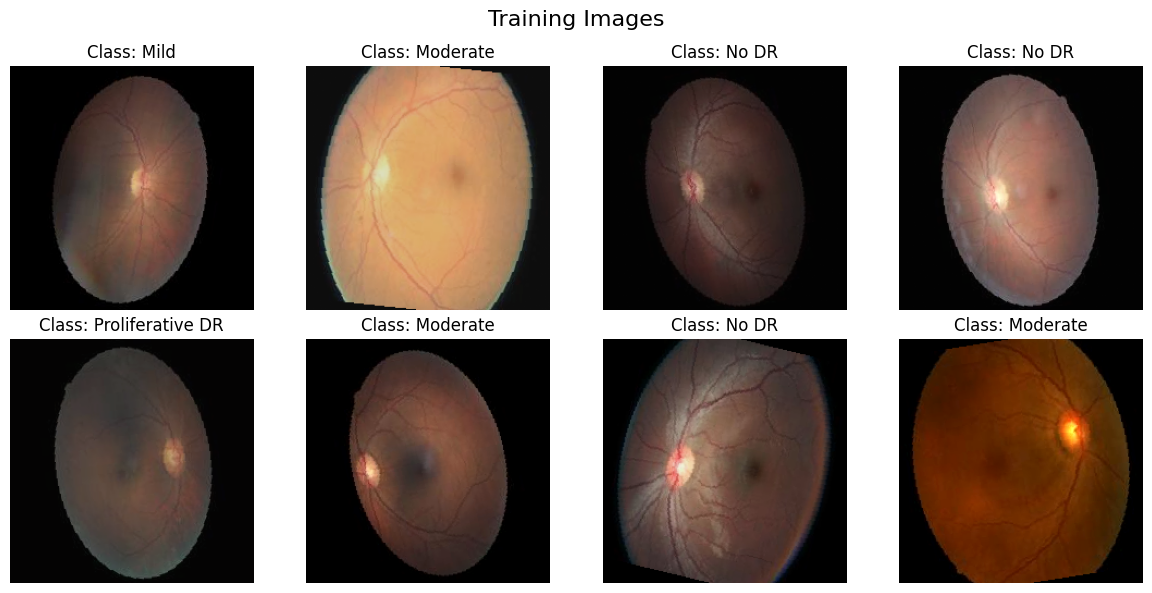

In [26]:
# Visualize Images
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# Get a batch of images
images, labels = next(iter(train_loader))

# Denormalize images for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
images_display = images[:8] * std + mean  # Undo normalization

# Plot
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Training Images', fontsize=16)

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

for idx, ax in enumerate(axes.flat):
    img = images_display[idx].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)  # Clip to [0, 1]
    
    ax.imshow(img)
    ax.set_title(f"Class: {class_names[labels[idx].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('SplitDATA\\logs\\sample_images.png', dpi=150)
plt.show()

#print(" Images displayed!")

In [27]:
# creating FULL DeiT student model
student_model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=0.0,
    drop_path_rate=0.1
).to(DEVICE)

total_params = sum(p.numel() for p in student_model.parameters())
trainable_params = sum(p.numel() for p in student_model.parameters() if p.requires_grad)

print(f"Student model: {MODEL_NAME}")
print(f"Total params: {total_params/1e6:.2f}M")
print(f"Trainable params: {trainable_params/1e6:.2f}M")

Student model: deit_small_distilled_patch16_224
Total params: 21.67M
Trainable params: 21.67M


In [28]:
from tqdm import tqdm
from sklearn.metrics import f1_score

os.makedirs("SplitDATA/checkpoints", exist_ok=True)
os.makedirs("SplitDATA/logs", exist_ok=True)

teacher_ckpt = "SplitDATA/checkpoints/teacher_regnety160_best.pth"

teacher_model = timm.create_model(
    TEACHER_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
).to(DEVICE)

def train_teacher_if_needed(model, train_loader, val_loader, ckpt_path, epochs=TEACHER_EPOCHS):
    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        print("Loaded existing teacher checkpoint")
        return model

    criterion_teacher = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=0.1
    )

    optimizer_teacher = optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=WEIGHT_DECAY
    )

    scheduler_teacher = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_teacher,
        T_max=epochs,
        eta_min=1e-6
    )

    best_val_f1 = -1.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"Teacher Train {epoch+1}/{epochs}", leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer_teacher.zero_grad()
            outputs = model(images)
            loss = criterion_teacher(outputs, labels)
            loss.backward()
            optimizer_teacher.step()

            running_loss += loss.item()

        model.eval()
        val_preds, val_labels = [], []

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Teacher Val {epoch+1}/{epochs}", leave=False):
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)

                outputs = model(images)
                preds = outputs.argmax(dim=1)

                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_f1 = f1_score(val_labels, val_preds, average="macro")
        scheduler_teacher.step()

        print(
            f"Teacher Epoch {epoch+1}/{epochs} | "
            f"Loss: {running_loss/len(train_loader):.4f} | "
            f"Val Macro-F1: {val_f1:.4f}"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), ckpt_path)
            print("Saved best teacher")

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    print(f"Teacher ready | Best Val Macro-F1: {best_val_f1:.4f}")
    return model

teacher_model = train_teacher_if_needed(
    teacher_model,
    train_loader,
    val_loader,
    teacher_ckpt,
    epochs=TEACHER_EPOCHS
)

teacher_model.eval()
for p in teacher_model.parameters():
    p.requires_grad = False

Loaded existing teacher checkpoint


/tmp/ipykernel_496917/4153152305.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))


In [ ]:

import torch.optim as optim
# Distillation training setup
criterion_cls = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

# KL divergence for soft distillation
criterion_dist = nn.KLDivLoss(reduction="batchmean")

optimizer = optim.AdamW(
    student_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

print(f"ALPHA = {ALPHA}, TAU = {TAU}")

ALPHA = 0.5, TAU = 1.0


In [30]:

# Full DeiT distillation training
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score


def unpack_student_outputs(outputs):
    if isinstance(outputs, (tuple, list)) and len(outputs) == 2:
        return outputs[0], outputs[1]
    return outputs, outputs

log_path = "SplitDATA/logs/training_log.txt"
os.makedirs(os.path.dirname(log_path), exist_ok=True)

with open(log_path, "w") as f:
    f.write("Epoch,  TrainLoss  ,TrainAcc,  TrainF1,   ValLoss,  ValAcc,  ValBalAcc,  ValF1\n")

best_val_f1 = -1.0
patience_counter = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_bal_acc": [],
    "val_f1": []
}

for epoch in range(1, NUM_EPOCHS + 1):
    student_model.train()
    teacher_model.eval()

    train_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch} Train", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with torch.no_grad():
            teacher_logits = teacher_model(images)

        student_outputs = student_model(images)
        cls_logits, dist_logits = unpack_student_outputs(student_outputs)

        # hard-label classification loss
        loss_cls = criterion_cls(cls_logits, labels)

        # soft distillation loss
        loss_dist = criterion_dist(
            F.log_softmax(dist_logits / TAU, dim=1),
            F.softmax(teacher_logits / TAU, dim=1)
        ) * (TAU ** 2)

        # total loss
        loss = (1 - ALPHA) * loss_cls + ALPHA * loss_dist

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = ((cls_logits + dist_logits) / 2.0).argmax(dim=1)
        train_preds.extend(preds.detach().cpu().numpy())
        train_labels.extend(labels.detach().cpu().numpy())

    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)
    train_f1 = f1_score(train_labels, train_preds, average="macro")

    student_model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch} Val", leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            teacher_logits = teacher_model(images)

            student_outputs = student_model(images)
            cls_logits, dist_logits = unpack_student_outputs(student_outputs)

            # hard-label classification loss
            loss_cls = criterion_cls(cls_logits, labels)

            # soft distillation loss
            loss_dist = criterion_dist(
                F.log_softmax(dist_logits / TAU, dim=1),
                F.softmax(teacher_logits / TAU, dim=1)
            ) * (TAU ** 2)

            # total loss
            loss = (1 - ALPHA) * loss_cls + ALPHA * loss_dist

            val_loss += loss.item()

            final_logits = (cls_logits + dist_logits) / 2.0
            preds = final_logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    val_bal_acc = balanced_accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average="macro")

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_bal_acc"].append(val_bal_acc)
    history["val_f1"].append(val_f1)

    log_line = (
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"TrLoss: {train_loss:.4f} | TrAcc: {train_acc*100:.2f}% | TrF1: {train_f1:.4f} | "
        f"VlLoss: {val_loss:.4f} | VlAcc: {val_acc*100:.2f}% | "
        f"VlBalAcc: {val_bal_acc:.4f} | VlF1: {val_f1:.4f}"
    )
    print(log_line)

    with open(log_path, "a") as f:
        f.write(
            f"{epoch},{train_loss:.4f},{train_acc:.4f},{train_f1:.4f},"
            f"{val_loss:.4f},{val_acc:.4f},{val_bal_acc:.4f},{val_f1:.4f}\n"
        )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(student_model.state_dict(), "SplitDATA/checkpoints/best_distilled_deit_model.pth")
        print("Saved best distilled student")

        with open(log_path, "a") as f:
            f.write(f" Best model saved at epoch {epoch} | ValF1: {val_f1:.4f}\n")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            with open(log_path, "a") as f:
                f.write(f"Early stopping at epoch {epoch}\n")
            break

print(f"Training complete | Best Val Macro-F1: {best_val_f1:.4f}")

with open(log_path, "a") as f:
    f.write(f"\nTraining complete | Best Val Macro-F1: {best_val_f1:.4f}\n")

Epoch 01/12 | TrLoss: 1.2866 | TrAcc: 72.83% | TrF1: 0.1746 | VlLoss: 1.7855 | VlAcc: 73.50% | VlBalAcc: 0.2000 | VlF1: 0.1695
Saved best distilled student


Epoch 02/12 | TrLoss: 1.2716 | TrAcc: 73.17% | TrF1: 0.1699 | VlLoss: 1.7862 | VlAcc: 73.50% | VlBalAcc: 0.2000 | VlF1: 0.1695


Epoch 03/12 | TrLoss: 1.2704 | TrAcc: 73.17% | TrF1: 0.1730 | VlLoss: 1.7946 | VlAcc: 73.39% | VlBalAcc: 0.2011 | VlF1: 0.1719
Saved best distilled student


Epoch 04/12 | TrLoss: 1.2689 | TrAcc: 72.70% | TrF1: 0.1763 | VlLoss: 1.8010 | VlAcc: 73.50% | VlBalAcc: 0.2000 | VlF1: 0.1695


Epoch 05/12 | TrLoss: 1.2665 | TrAcc: 72.88% | TrF1: 0.1764 | VlLoss: 1.7859 | VlAcc: 73.50% | VlBalAcc: 0.2000 | VlF1: 0.1695


...

Epoch 08/12 | TrLoss: 1.2610 | TrAcc: 71.15% | TrF1: 0.1919 | VlLoss: 1.8032 | VlAcc: 68.65% | VlBalAcc: 0.2475 | VlF1: 0.1885
Saved best distilled student


Epoch 09/12 | TrLoss: 1.2584 | TrAcc: 70.52% | TrF1: 0.1983 | VlLoss: 1.7933 | VlAcc: 71.24% | VlBalAcc: 0.2460 | VlF1: 0.2011
Saved best distilled student


Epoch 10/12 | TrLoss: 1.2506 | TrAcc: 69.85% | TrF1: 0.2074 | VlLoss: 1.7966 | VlAcc: 69.98% | VlBalAcc: 0.2611 | VlF1: 0.2054
Saved best distilled student


Epoch 11/12 | TrLoss: 1.2481 | TrAcc: 69.25% | TrF1: 0.2216 | VlLoss: 1.8011 | VlAcc: 71.17% | VlBalAcc: 0.2645 | VlF1: 0.2198
Saved best distilled student


Epoch 12/12 | TrLoss: 1.2422 | TrAcc: 69.68% | TrF1: 0.2232 | VlLoss: 1.8036 | VlAcc: 70.55% | VlBalAcc: 0.2684 | VlF1: 0.2253
Saved best distilled student
Training complete | Best Val Macro-F1: 0.2253


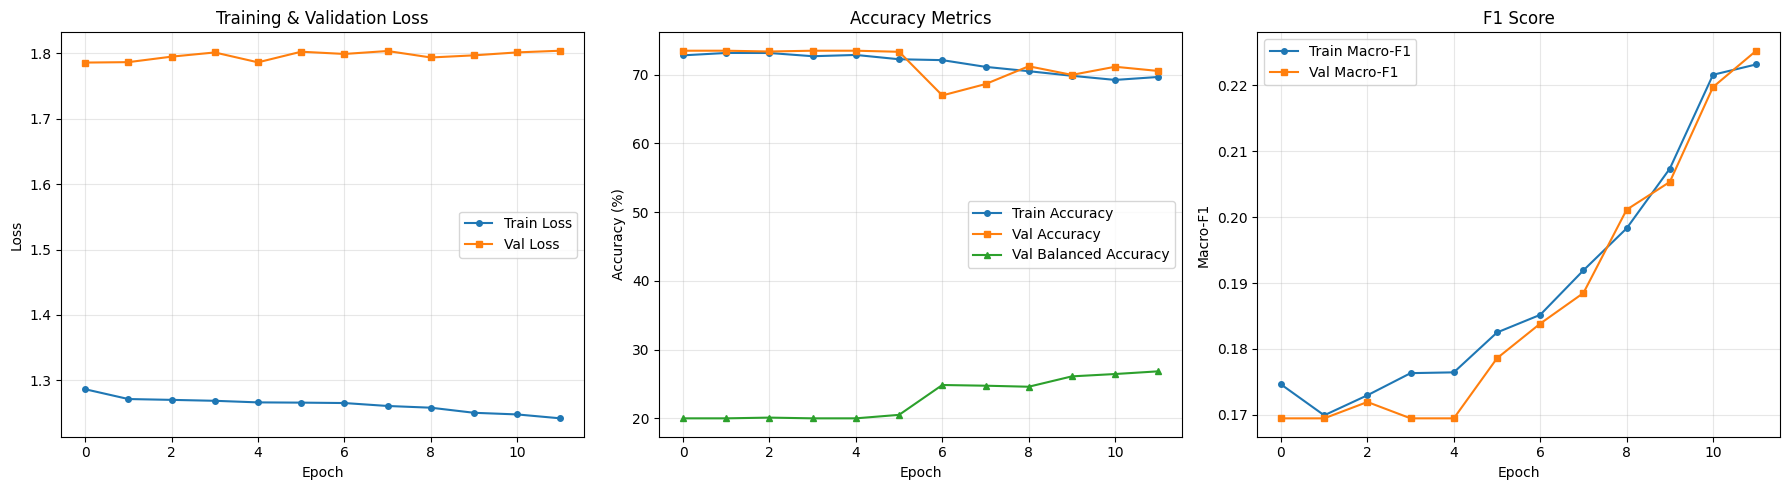

In [31]:
# plot training results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([x * 100 for x in history['train_acc']], label='Train Accuracy', marker='o', markersize=4)
axes[1].plot([x * 100 for x in history['val_acc']], label='Val Accuracy', marker='s', markersize=4)
axes[1].plot([x * 100 for x in history['val_bal_acc']], label='Val Balanced Accuracy', marker='^', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Metrics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['train_f1'], label='Train Macro-F1', marker='o', markersize=4)
axes[2].plot(history['val_f1'], label='Val Macro-F1', marker='s', markersize=4)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro-F1')
axes[2].set_title('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('SplitDATA/logs/training_curves_distilled_deit.png', dpi=150)
plt.show()

In [44]:
# test on test set

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score,
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

student_model = timm.create_model(
    'deit_small_distilled_patch16_224',
    pretrained=False,
    num_classes=5,
    drop_rate=0.0,
    drop_path_rate=0.1
).to(device)

student_model.load_state_dict(
    torch.load("SplitDATA/checkpoints/best_distilled_deit_model.pth", map_location=device)
)
student_model.eval()

test_preds = []
test_labels = []
test_probs = []

def unpack_student_outputs(outputs):
    if isinstance(outputs, (tuple, list)) and len(outputs) == 2:
        return outputs[0], outputs[1]
    return outputs, outputs

print("Testing on test set...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = student_model(images)
        cls_logits, dist_logits = unpack_student_outputs(outputs)
        final_logits = (cls_logits + dist_logits) / 2.0

        probs = F.softmax(final_logits, dim=1)
        preds = final_logits.argmax(dim=1)

        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_probs = np.array(test_probs)
test_preds = np.array(test_preds)
test_labels = np.array(test_labels)

cm = confusion_matrix(test_labels, test_preds)

test_acc = accuracy_score(test_labels, test_preds)
test_bal_acc = balanced_accuracy_score(test_labels, test_preds)
macro_precision = precision_score(test_labels, test_preds, average='macro', zero_division=0)
macro_recall = recall_score(test_labels, test_preds, average='macro', zero_division=0)
macro_f1 = f1_score(test_labels, test_preds, average='macro', zero_division=0)
weighted_f1 = f1_score(test_labels, test_preds, average='weighted', zero_division=0)
qwk = cohen_kappa_score(test_labels, test_preds, weights='quadratic')
mcc = matthews_corrcoef(test_labels, test_preds)

try:
    multiclass_auc = roc_auc_score(test_labels, test_probs, multi_class='ovr', average='macro')
except ValueError:
    multiclass_auc = None


print("TEST RESULTS\n\n")
print(f"Accuracy                 : {test_acc:.4f}")
print(f"Balanced Accuracy        : {test_bal_acc:.4f}")
print(f"Macro Precision          : {macro_precision:.4f}")
print(f"Macro Recall             : {macro_recall:.4f}")
print(f"Macro F1                 : {macro_f1:.4f}")
print(f"Weighted F1              : {weighted_f1:.4f}")
print(f"Quadratic Weighted Kappa : {qwk:.4f}")
print(f"Matthews Corrcoef        : {mcc:.4f}")
print(f"Macro ROC-AUC (OvR)      : {multiclass_auc if multiclass_auc is not None else 'Not available'}")

print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names, digits=4, zero_division=0))

print("Confusion Matrix:")
print(cm)

print("\nClass-wise sensitivity / specificity:")
for i, class_name in enumerate(class_names):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - (tp + fn + fp)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    print(f"{class_name:15s} | Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}")



test_log_path = "SplitDATA/logs/test_results.txt"
os.makedirs(os.path.dirname(test_log_path), exist_ok=True)

with open(test_log_path, "w") as f:


    f.write("TEST RESULTS\n")
    f.write(f"Accuracy                 : {test_acc:.4f}\n")
    f.write(f"Balanced Accuracy        : {test_bal_acc:.4f}\n")
    f.write(f"Macro Precision          : {macro_precision:.4f}\n")
    f.write(f"Macro Recall             : {macro_recall:.4f}\n")
    f.write(f"Macro F1                 : {macro_f1:.4f}\n")
    f.write(f"Weighted F1              : {weighted_f1:.4f}\n")
    f.write(f"Quadratic Weighted Kappa : {qwk:.4f}\n")
    f.write(f"Matthews Corrcoef        : {mcc:.4f}\n")

    if multiclass_auc is not None:
        f.write(f"Macro ROC-AUC (OvR)      : {multiclass_auc:.4f}\n")
    else:
        f.write("Macro ROC-AUC (OvR)      : Not available\n")

    f.write("\nClassification Report:\n")
    f.write(classification_report(
        test_labels,
        test_preds,
        target_names=class_names,
        digits=4,
        zero_division=0
    ))
    f.write("\n")

    f.write("\nConfusion Matrix:\n")
    f.write(np.array2string(cm))
    f.write("\n")

    f.write("\nClass-wise sensitivity / specificity:\n")

    for i, class_name in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        f.write(f"{class_name:15s} | Sensitivity: {sensitivity:.4f} | Specificity: {specificity:.4f}\n")

print(f"\nTest results saved to: {test_log_path}")
    

/tmp/ipykernel_496917/3837819340.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("SplitDATA/checkpoints/best_distilled_deit_model.pth", map_location=device)


Testing on test set...


Testing: 100%|██████████| 220/220 [00:10<00:00, 21.19it/s]


TEST RESULTS


Accuracy                 : 0.6984
Balanced Accuracy        : 0.2570
Macro Precision          : 0.3893
Macro Recall             : 0.2570
Macro F1                 : 0.2162
Weighted F1              : 0.6176
Quadratic Weighted Kappa : 0.1383
Matthews Corrcoef        : 0.0736
Macro ROC-AUC (OvR)      : 0.6323771917152923

Classification Report:
               precision    recall  f1-score   support

        No DR     0.7477    0.9407    0.8331      5162
         Mild     0.0000    0.0000    0.0000       490
     Moderate     1.0000    0.0009    0.0019      1059
       Severe     0.1000    0.1193    0.1088       176
Proliferative     0.0988    0.2238    0.1370       143

     accuracy                         0.6984      7030
    macro avg     0.3893    0.2570    0.2162      7030
 weighted avg     0.7041    0.6984    0.6176      7030

Confusion Matrix:
[[4856    0    0  102  204]
 [ 467    0    0   13   10]
 [ 927    0    1   62   69]
 [ 146    0    0   21    9]
 [  99    0    

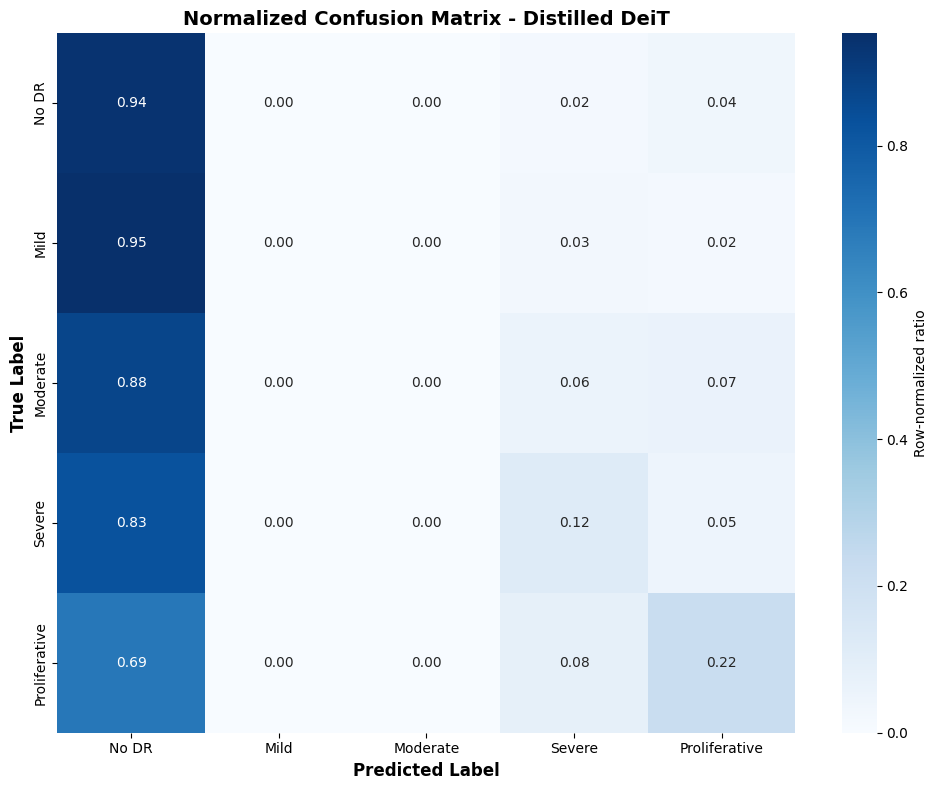

✓ Confusion matrix saved!


In [36]:
# plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Row-normalized ratio'},
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Normalized Confusion Matrix - Distilled DeiT', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('SplitDATA/logs/confusion_matrix_distilled_deit.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved!")

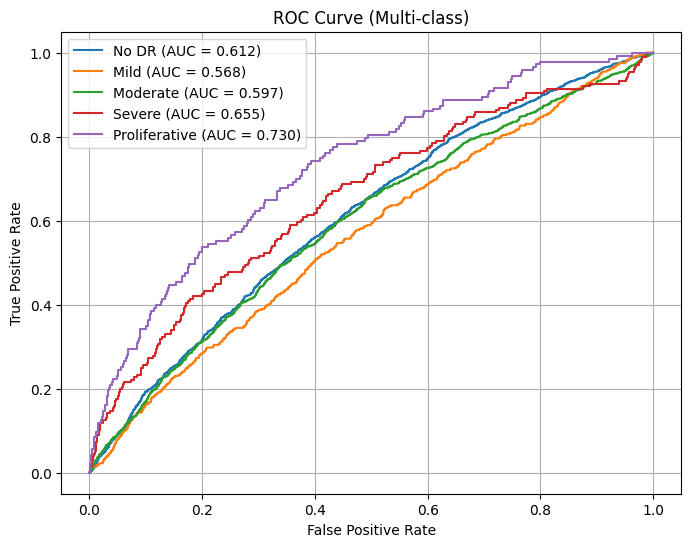

In [43]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(test_labels, classes=[0,1,2,3,4])
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], test_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

# random baseline
#plt.plot([0,1], [0,1], 'k--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.grid()

plt.savefig("SplitDATA/logs/roc_curve.png", dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import average_precision_score
ap_per_class = []

for i in range(n_classes):
    ap = average_precision_score(y_true_bin[:, i], test_probs[:, i])
    ap_per_class.append(ap)

mAP = np.mean(ap_per_class)

print("\nAverage Precision per class:")
for i, ap in enumerate(ap_per_class):
    print(f"{class_names[i]}: {ap:.4f}")

print(f"\nmAP: {mAP:.4f}")


Average Precision per class:
No DR: 0.7977
Mild: 0.0889
Moderate: 0.2032
Severe: 0.0622
Proliferative: 0.0699

mAP: 0.2444
